# Projekt Instrumenty Finansowe


## Wstęp, założenia i nomenkulatura


### Słowo wstępu

W tym projekcie skupimy się na ukazaniu niuansów oszczędności emerytalnych, przeprowadzimy parę symulacji by zobaczyć jak się one zachowują. Na początku założmy dużo nieprawdziwych rzeczy o świecie by uprościć model obliczeniowy jednak w kolejnych eksperymentach będziemy się coraz bardziej przybliżyć do świata realnego. 

### Słowniczek

| Symbol | Opis |
|--------|------|
| **Π** | Roczna realna stopa inflacji |
| **c** | Roczna realna stopa zwrotu z obligacji |
| **I** | Roczna realna stopa wzrostu pensji |
| **t₀** | Rok, w którym rozpoczniecie odkładanie na emeryturę |
| **T** | Rok, w którym planujecie przejście na emeryturę |
| **tₐ** | Rok, w którym umrzecie |
| **p** | Procent pensji, jaki odkładacie na emeryturę w każdym miesiącu - funkcja pozostałych parametrów |

### Założenia


Poniżej wymieniono kluczowe założenia początkowego modelu:
1. **Stałe stopy procentowe i wskaźniki w czasie** – Zakładamy, że inflacja ($\Pi$), zwrot z obligacji ($c$) oraz wzrost pensji ($I$) są stałe przez dziesiątki lat. W rzeczywistości podlegają one cyklom koniunkturalnym i rynkowym wahaniom. *Mitygacja: Zastosowanie symulacji stochastycznych (Monte Carlo) oparte o historyczne rynkowe stopy zwrotu by włączyć element losowości do systemu zapisu stóp referencyjnych.*
2. **Znana i stała długość życia ($t_d$)** – Model zakłada ściśle określoną barierę zgonu czyli rok wygaśnięcia puli kapitału. Reprezentuje to ukryte *ryzyko długowieczności* i życie bez zasięgu portfela. *Mitygacja: Przewartościowanie portfela oraz posługiwanie się tablicami długości trwania życia GUS lub dożywotnią rentą zabezpieczającą na starość na wypadek przetrwania bazy kapitału.*
3. **Ciągłość zatrudnienia** – Ten model implikuje idealne, gładkie i nieprzerwane rośnięcie pensji przy ciągłości zatrudnienia. Nie dba o okna bezrobocia, czas rekonwalescencji czy też o wychowanie potomków.*Mitygacja: Parametryzacja lat braku wpłat oraz gwałtowniejszych skoków w zarobkach po pozycjonowaniu się w awertykalny profil na swoim stanowisku.*
4. **Brak podatków od zysków kapitałowych przy 100% alokacyjności obligacyjnej** – Przewidujemy brak opłat i brak podatków z obrocie (tzw. podatek Belki w Polsce), jak również upraszczamy portfel do najbardziej pasywnych papierów (obligacji). *Mitygacja: Uwzględnienie ulg podatkowych poprzez portfele typu IKE / IKZE i konstrukcja zdywersyfikowanych pakietów docelowych (target-date funds), wprowadzających dynamiczność alokowania w ryzyko względem lat trwania w oszczędnościach.*


## Zadanie 1

**Treść:**
Przy podanych danych ($\Pi = 0.02, c = 0.03, I = 0.05, t_0 = 0, T = 40, t_d = 60$) policz $p$ takie, że Twoja pierwsza emerytura będzie równa ostatniej pensji, a następnie będzie rosnąć w takim samym tempie jak inflacja.

### Rozwiązanie

Nasze życie finansowe w modelu podzielone jest na dwie fazy: **akumulację** (pracę) oraz **dekumulację** (emeryturę). Wyliczymy teraz wszystko, dyskontując obydwa te strumienie finansowe na moment początkowy, czyli bieżący rok $t_0$ (nasze dzisiejsze *Present Value - PV*). 

Ponieważ wpłaty są miesięczne, podane w zadaniu roczne stopy realne zamieniamy na nominalne używając równania Fishera, a potem przeliczamy na miesięczne:
- Z równania Fishera: $r_{nom} = (1 + c)(1 + \Pi) - 1$, $g_{nom} = (1 + I)(1 + \Pi) - 1$
- Stopy miesięczne: $\pi_m = (1 + \Pi)^{1/12} - 1$, $r_m = (1 + r_{nom})^{1/12} - 1$, $g_m = (1 + g_{nom})^{1/12} - 1$

**Faza I: Praca ($N_w$ miesięcy)**
Zaczynamy zarabiać $S_0$ (wzór działa proporcjonalnie, więc $S_0$ potem się skróci, np. $S_0=1$). Odkładamy z pensji kwotę $p \cdot S_k$, gdzie pensja rośnie: $S_k = S_0(1+g_m)^{k-1}$.
Wartość bieżąca na moment $t_0$ (tu i teraz) wszystkich odkładanych w przyszłości składek to ich zdyskontowana suma (*Present Value - $PV_{acc}$*):
$$PV_{acc} = p \cdot S_0 \sum_{k=1}^{N_w} \frac{(1+g_m)^{k-1}}{(1+r_m)^k}$$

**Faza II: Emerytura ($N_e$ miesięcy)**
Ostatnia pobrana pensja (w miesiącu przed emeryturą) to $S_{last} = S_0(1+g_m)^{N_w-1}$.
Zgodnie z wymaganiami zadania nasza pierwsza emerytura wyliczana jest jako równa tej ostatniej pensji: $E_1 = S_{last}$.
Przez resztę życia pobieramy emeryturę rosnącą wraz z inflacją $\pi_m$. Ponieważ wszystkie te wypłaty zaczynają się dopiero *po* okresie pracy ($N_w$), musimy je zdyskontować dwuetapowo ściągając je na moment początkowy $t_0$: najpierw o $j$ miesięcy fazy pobierania emerytury, a jako że w czasie $t_0$ jesteśmy wciąż $N_w$ miesięcy od ich startu – dodatkowy czas przerwy całego życia zawodowego (*Present Value - $PV_{decum}$*):
$$PV_{decum} = \frac{E_1}{(1+r_m)^{N_w}} \sum_{j=1}^{N_e} \frac{(1+\pi_m)^{j-1}}{(1+r_m)^j}$$

Bilansując pulę wkładów z dzisiejszą wartością wypłat (w punkcie $t_0$), $PV_{acc} = PV_{decum}$, wyprowadzimy $p$:
$$p = \frac{PV_{decum} \text{ (dla } S_0=1)}{PV_{acc} \text{ bez } p \text{ (dla } S_0=1)}$$

In [13]:
import numpy as np

def policz_p(Pi, c, I, t0, T, td):
    # Parametry bazowe są rocznymi stopami realnymi. 
    # Dla poprawnego modelu obliczamy stopy nominalne wynikające z równania Fishera:
    r_nom = (1 + c) * (1 + Pi) - 1
    g_nom = (1 + I) * (1 + Pi) - 1
    
    # Przeliczenie rocznych stóp na rzędy miesięczne
    pi_m = (1 + Pi)**(1/12) - 1
    r_m = (1 + r_nom)**(1/12) - 1
    g_m = (1 + g_nom)**(1/12) - 1
    
    # Okresy w miesiącach
    N_w = (T - t0) * 12 # Akumulacja kapitału
    N_e = (td - T) * 12 # Dekumulacja kapitału (emerytura)
    
    S0 = 1.0 # Początkowe zarobki w celu uproszczenia (skracają się z obydwu stron równania)
    
    # Akumulacja - liczymy Wartość Bieżącą (PV) wszystkich wpłaconych składek punktu t0
    k = np.arange(1, N_w + 1)
    pv_acc_skladowe = (1 + g_m)**(k - 1) / (1 + r_m)**k
    pv_acc_mnoznik = np.sum(pv_acc_skladowe) 
    
    # Pierwsza Emerytura zrównana z ostatnią wniesioną pensją 
    E1 = S0 * (1 + g_m)**(N_w - 1)
    
    # Dekumulacja - liczymy Wartość Bieżącą (PV) na moment t0 (cofnięcie również o Nw)
    j = np.arange(1, N_e + 1)
    pv_decum_skladowe = (1 + pi_m)**(j - 1) / (1 + r_m)**j
    # Dodatkowe dyskontowanie całego bloku o okres pracy Nw do momentu t0
    pv_decum_total = (E1 / (1 + r_m)**N_w) * np.sum(pv_decum_skladowe)
    
    # Wyciągnijmy p z równości PV_acc * p = PV_decum
    p = pv_decum_total / pv_acc_mnoznik
    
    return p

# Dane z zadania
Pi_val, c_val, I_val = 0.02, 0.03, 0.05
t0_val, T_val, td_val = 0, 40, 60

p_optymalne = policz_p(Pi_val, c_val, I_val, t0_val, T_val, td_val)

print("=== ZADANIE 1: WYNIK ===")
print("Aby zachować swoją emeryturę na zadanym poziomie, odkładany procent p to:")
print(f"{p_optymalne * 100:.2f}% miesięcznej pensji.")

=== ZADANIE 1: WYNIK ===
Aby zachować swoją emeryturę na zadanym poziomie, odkładany procent p to:
53.91% miesięcznej pensji.


### Analiza wyników (Zadanie 1)

Dla przyjętych danych model wyliczył, że odkładany procent $p \approx 53.91\%$. Jest to bardzo duży odsetek wynikający z tego, że założyliśmy wysoką stopę zwrotu z włożonej pracy własnej (pensja realnie rośnie o $5\%$ każdego roku) i przy tym stosunkowo niski, bezpieczny przyrost odłożonych oszczędności z samych obligacji (zwrot realny zaledwie $3\%$). Utrzymanie tak niesamowicie mocnego i stale rosnącego standardu życia pod koniec kariery i rzutowanie go na kilkadziesiąt lat bezrobocia w czasie emerytury wymaga gigantycznych wyrzeczeń i inwestowania z każdej pensji ogromnej części budżetu ponad dopuszczalne normy większości gospodarstw domowych.

## Zadanie 2

**Treść:**
Zbadaj wrażliwość $p$ na parametry modelu. Poszukaj zależności między parametrami modelu, i omów które z nich grają największą rolę.

### Rozwiązanie

Do zbadania wrażliwości wykorzystamy zasadę *ceteris paribus*. Będziemy testować wartość odkładanego procenta $p$ modyfikując daną stopę inflacyjną ($\Pi$) oraz stopę zwrotu z obligacji ($c$). Zobaczymy, jak wyliczone przez nas $p$ reaguje na zmiany poszczególnych rynkowych stóp. Następnie zwizualizujemy funkcję zależności za pomocą biblioteki `matplotlib`.


=== Zadanie 2 ===
Wrażliwość odkładanej części p na korekty stopy inflacji(Π) oraz zwrotu z obligacji(c):



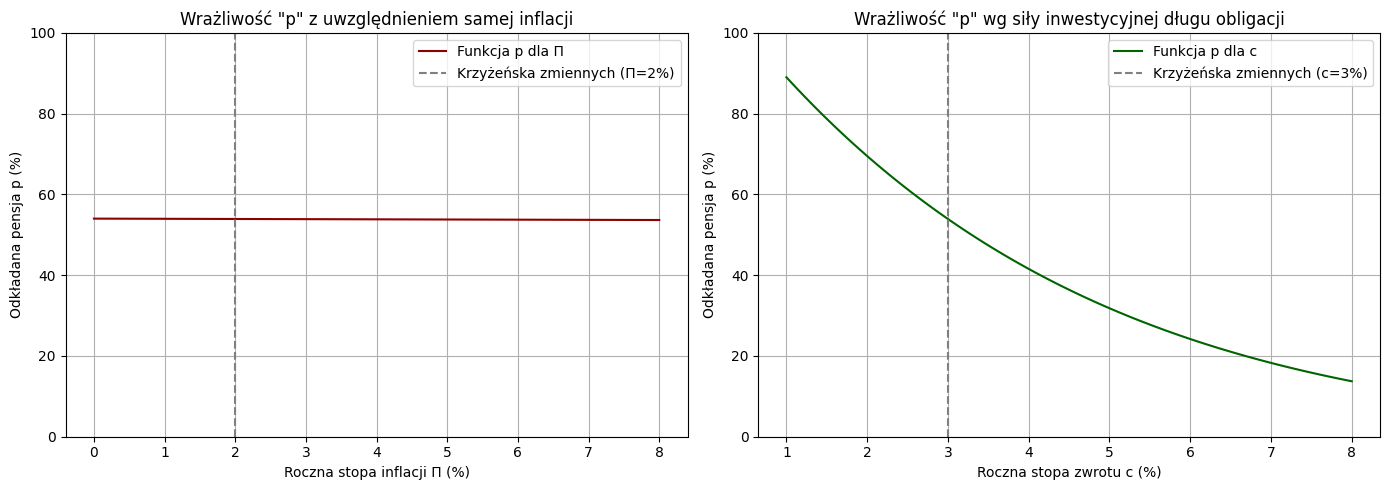

In [6]:
import matplotlib.pyplot as plt

# Zgodnie z zasadą ceteris paribus manewrujemy dwiema strefami (wpływ Inflacji oraz Zyski obligacyjne).

pi_range = np.linspace(0.00, 0.08, 100)
p_for_pi = [policz_p(pi, c_val, I_val, t0_val, T_val, td_val) for pi in pi_range]

c_range = np.linspace(0.01, 0.08, 100)
p_for_c = [policz_p(Pi_val, c, I_val, t0_val, T_val, td_val) for c in c_range]

print("\n=== Zadanie 2 ===")
print("Wrażliwość odkładanej części p na korekty stopy inflacji(Π) oraz zwrotu z obligacji(c):\n")

plt.figure(figsize=(14, 5))

# Wrażliwość Π
plt.subplot(1, 2, 1)
plt.plot(pi_range * 100, np.array(p_for_pi) * 100, color='darkred', label='Funkcja p dla Π')
plt.axvline(x=Pi_val*100, color='gray', linestyle='--', label='Krzyżeńska zmiennych (Π=2%)')
plt.title('Wrażliwość "p" z uwzględnieniem samej inflacji')
plt.xlabel('Roczna stopa inflacji Π (%)')
plt.ylabel('Odkładana pensja p (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

# Wrażliwość c
plt.subplot(1, 2, 2)
plt.plot(c_range * 100, np.array(p_for_c) * 100, color='darkgreen', label='Funkcja p dla c')
plt.axvline(x=c_val*100, color='gray', linestyle='--', label='Krzyżeńska zmiennych (c=3%)')
plt.title('Wrażliwość "p" wg siły inwestycyjnej długu obligacji')
plt.xlabel('Roczna stopa zwrotu c (%)')
plt.ylabel('Odkładana pensja p (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Analiza wyników (Zadanie 2)

**Wnioski odnośnie skali i zależności:**
1. **Niewrażliwość na czystą inflację ($\Pi$)**: Na lewym wykresie ułamek $p$ pozostaje równy. Wynika to z faktu, że skoro nasze zyski operacyjne ($I$) oraz zarabiane na lokatach ($c$) są zdefiniowane jako *stopy realne* chroniące siłę nabywczą pieniądza, system się doskonale "indeksuje".
2. **Kluczowa rola siły inwestowania (różnica wzrostu $I$ względem $c$)**: Jak zauważamy na wykresie po prawej stronie, gdy rynkowy realny dług rośnie, potrzebujemy składać o wiele mniejsze oszczędności finansujące resztę życia. Kiedy jednak $c$ zbiegnie do niskiego poziomu, nasz wymagany wskaźnik oszczędności potężnie rośnie! Najważniejszą zależnością w tym modelu jest wielość realnego przyrostu obligacyjno-wypłatowego ($c - I$). Aby portfel emerytalny zdołał nam sfinansować tak zawrotne tempo bogacenia i uchronił go w starości przed realną inflacją, nasza teka papierów powinna zarabiać co najmniej w stosunku na równi lub wyżej co nasza pensja. Zwiększając tę różnicę minimalizujemy potrzebę wyrzeczeń wpłat $p$.

## Zadanie 3

**Treść:**
Wypisz założenia powyższego modelu. Które z nich są najbardziej istotne? Jak można zrównoważyć problemy modelu i zmitygować kluczowe założenia, żeby nasze modelowanie było jak najbliższe rzeczywistości?

### Rozwiązanie

W tym zadaniu skupiamy się na krytycznym spojrzeniu na model. Chociaż problem założeń został już zasygnalizowany we Wstępie do projektu, sformalizujmy je tutaj i odpowiedzmy na pytania o ich istotność.

**1. Zidentyfikowane założenia z modelu deterministycznego:**
- **Stałość stóp (inflacji, obligacji, wzrostu pensji)**: Zakładamy, że bez ustanków, przez kilkadziesiąt lat nic się nie zmienia (stałe wartości $c, \Pi, I$).
- **Wiedza o dacie śmierci ($t_d$)**: Model zakłada perfekcyjną wiedzę o tym, kiedy nastąpi zgon. Oznacza to idealne zzerowanie kapitału zgromadzonego na koniec opłacania rent.
- **Stała podaż składek i brak przerw w karierze**: Idealna, liniowa kontynuacja zatrudnienia. Brak bezrobocia, brak odpoczynku, brak zmiany etatu na tańszy – procent $p$ jest odprowadzany nieustannie co miesiąc.
- **Brak obciążeń podatkowych i prowizji**: Model istnieje w próżni i systematyzuje wypłaty bez kosztów obsługi kont transakcyjnych czy podatku od zysków kapitałowych (podatek Belki w Polsce).

**2. Które z nich jest najbardziej istotne i dlaczego?**
Zdecydowanie **stałość stóp procentowych**. Długoterminowy układ kapitalizacji trwający odkładanie np. przez 40 lat i wypłacanie przez 20 sprawia, że występuje tu potężne ukryte niszczące ryzyko, zwane w finansach *ryzykiem sekwencji zwrotów* (Sequence of Returns Risk). Krach rynkowy lub wystrzał inflacyjny tuż przed czy po samym przejściu na emeryturę jest w stanie zrujnować portfel budowany latami znacznie szybciej, niż przewiduje liniowy algorytm matematyczny posiłkujący się zaledwie wygładzonymi "średnimi z rynku". 

**3. Jak zrównoważyć (mitygować), by model był bliższy rzeczywistości?**
- Najbardziej ryzykowne założenie (stałe stopy rynkowe) naprawia się poprzez zamianę modelu deterministycznego na stochastyczny – np. budując powszechnie znaną w bankowości **Symulację Monte Carlo**. Do symulacji portfela dołącza się wtedy faktyczną, historyczną zmienność rynków używając statystyki odchyleń standardowych tak dla stopy zwrotu jak i inflacji.
- Ryzyko bezbłędnej stałej daty śmierci bardzo łatwo zmitygować, wprowadzając dane dające obiektywne **Prawdopodobieństwo Przeżycia** czerpane od agencji rządowych np. *Tablice Trwania Życia GUS*.
- Ciągłość kariery mityguje się skryptami modelującymi okresowe luki bezrobocia.

Poniżej przygotowaliśmy bardzo prosty przykład skryptu wykonującego pre-wizualizację pierwszej, wymienionej koncepcji – zmiany sztywnej osi rynkowej z Zadania 1. Rozczepimy ten jeden punkt matematyczny na dziesięć losowych, realistycznie "pofalowanych uderzeniami rynkowymi" scenariuszy (tzw. ścieżek symulacji) dla stóp zwrotu portfela. Taki mechanizm omija podstawowy błąd "braku zmienności":

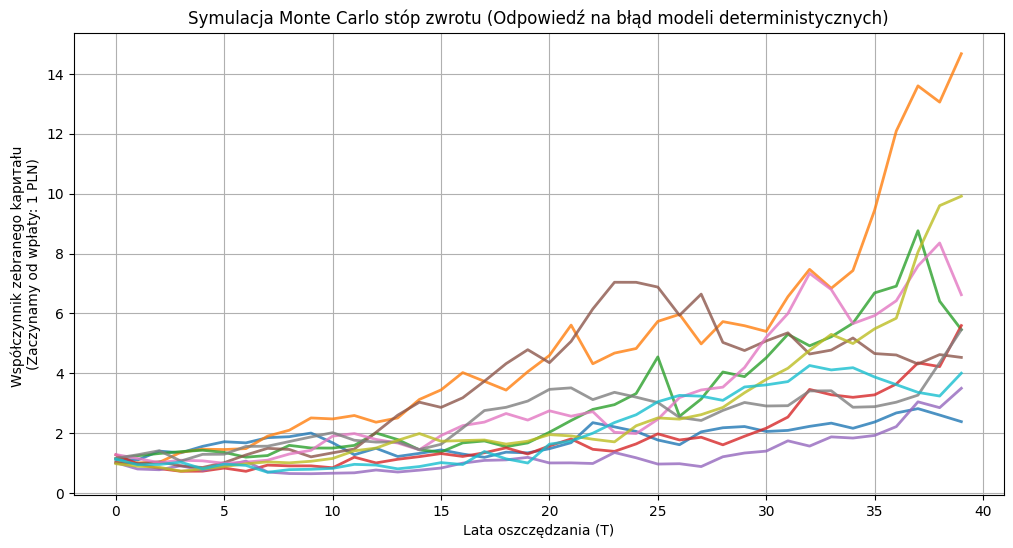

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Skrypt małych symulacji Monte Carlo w celu pokazania mitygacji stałych założeń
np.random.seed(42)

lata_symulacji = 40
liczba_scenariuszy = 10
# Załóżmy przykładowy rynek zarabiający średnio 5% 
srednia_stopa = 0.05 
# Ale dodajmy historyczną narzutkę ryzyka (odchylenie standardowe) z typowych portfeli (np. 15%)
odchylenie_std = 0.15 

# Symulacja rynków rocznych w 10 alternatywnych życiach
stopy_roczne = np.random.normal(loc=srednia_stopa, scale=odchylenie_std, size=(lata_symulacji, liczba_scenariuszy))

# Zobaczmy jak w tych ścieżkach zmienił by się kapitał startujący od zaledwie 1 złotówki (Kumulacja oprocentowania)
wartosc_portfela = np.cumprod(1 + stopy_roczne, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(wartosc_portfela, linewidth=2, alpha=0.8)
plt.title("Symulacja Monte Carlo stóp zwrotu (Odpowiedź na błąd modeli deterministycznych)")
plt.xlabel("Lata oszczędzania (T)")
plt.ylabel("Współczynnik zebranego kapитаłu \n(Zaczynamy od wpłaty: 1 PLN)")
plt.grid(True)
plt.show()

### Analiza wyników (Zadanie 3)

Wygenerowany powyżej wykres symulacji stochastycznej uświadamia jak bardzo nierealistyczne są matematyczne założenia o **stałych stopach**. Każda linia reprezentuje jedną, potencjalną przyszłość na rynku, na którym wprowadzono chociaż odrobinę zdrowego, losowego odchylenia standardowego wokół uśrednionej rynkowej marży! 

Patrząc gołym okiem:
1. Niektóre ścieżki (rynkowe byki) sprawijają, że nasza 1 początkowa złotówka wystrzeliwuje logarytmicznie wzwyż do ogromnych kwot i funduje wspaniałą starość.
2. Inne potrafią skończyć pod kreską początkowego kapitału, kompletnie zżarte przez niefortunny zbieg rynkowych załamań krótko na początku akumulowania.

**Podsumowanie:** Chociaż wzory na stałą lokatę świetnie sprawdzają się na etapie nauki oszczędzania (i pozwoliły nam określić bazowe *p* w zadaniu 1), to żeby model uchodził w nauce za "jak najbliższy rzeczywistości", stałą oś oprocentowań ($c$) należałoby w przyszłości wymienić w pełni na pule ścieżek z odchyleniami, mitygując tak twarde wyjęte z powietrza deklaracje długoterminowe.

## Zadanie 4

**Treść:**
Załóżmy, że mamy do dyspozycji drugie aktywo - indeks giełdowy
- $q_u$ - roczna realna stopa zwrotu z prawdopodobieństwem $p_u$
- $q_d$ - roczna realna stopa zwrotu z prawdopodobieństwem $p_d$

Zaproponuj realistyczne wartości $q_u, q_d, p_u, p_d$ jako punkt wyjściowy. W jaki sposób dostępność drugiego aktywa zmienia Twoje podejście do inwestycji? Zaproponuj nowy portfel inwestycyjny, który uważasz za optymalny i uzasadnij.

### Rozwiązanie

Wielu doradców majątkowych mocno zaleca na dłuższą metę rynki akcyjne, mimo ich cyklicznych wahań. Spróbujmy za pomocą dostępnych rynkowych danych i modelu dwumianowego sparametryzować zachowanie typowego szerokiego indeksu (np. amerykańskiego *S&P 500* lub globalnego *MSCI World*).

**1. Realistyczne wartości wyjściowe dla Indeksu Giełdowego:**
W modelu dwumianowym po upływie roku akcje mogą wzrosnąć (stopa $q_u$, sytuacja hossy) lub spaść (stopa $q_d$, sytuacja bessy). Patrząc historycznie na szerokie indeksy globalne, częstotliwość występowania dodatnich lat jest znacznie wyższa niż załamań rynkowych. Zaproponujmy wyjściowo takie parametry szacunkowe:
- $q_u = 0.15$ ($15\%$ wzrost realny ponad bieżącą inflację)
- $p_u = 0.70$ (Hossa. Giełdy rosną średnio z historycznym rzędem $70\%$ lat)
- $q_d = -0.10$ ($10\%$ tąpnięcie. Spadek rynku, realnie tracimy)
- $p_d = 0.30$ (Bessa. Giełdy wygasają po cyklach około $30\%$ lat z badanej dziedziny)

Oczekiwana matematyczna roczna stopa zwrotu (wartość oczekiwana) w takim rozkładzie to $\mathbb{E}[q]$:
$$\mathbb{E}[q] = p_u \cdot q_u + p_d \cdot q_d = 0.70 \cdot 0.15 + 0.30 \cdot (-0.10) = 0.105 - 0.030 = 0.075 \ (7.5\%)$$
Ten indeks statystycznie oferuje $7.5\%$ realnego przyrostu rocznie. Mają wyższy uśredniony zwrot niż bezpiecznie odkładane obligacje ($3\%$) pociągają jednak za sobą wysokowariancyjne ryzyka nagłego spadku zgromadzonego kapitału portfela (tzw. obsunięcie na wykresie - _drawdown_).

**2. Jak drugie aktywo całkowicie zmienia podejście?**
Otwiera pole analiz finansowych nazywane *Dywersyfikacją portfela*. Ponieważ mamy dostęp do aktywów ryzykownych z wyższą premią i aktywów płaskich dających bezpieczeństwo, racjonalnym jest mieszać je ze sobą. Często do zbierania pieniędzy pod wysoką oczekiwaną stopą bazuje się akcje a dla zapobiegania upadkom obniża loty i chroni pieniądze obligacjonalnie.

**3. Propozycja optymalnego portfela (klasyka rynkowa The 60/40)**
Bardzo popularnym rynkowo rozegraniem pozwalającym bezpiecznie dożyć emerytury jest skonstruowanie portfela uśrednionego o prostej wadze: 
- 60% Alokacji w Akcje giełdy indeksu (wyciągają wynik do przodu w górę)
- 40% Alokacji w Obligacje Skarbowe (działają jak twardy pancerz przeciw krachom).

Model dla zwrotu na portfelu ($c_{mix}$) używa proporcjowania względem kapitału i ma docelową oczekiwaną roczną formację oprocentowania:
$$c_{mix} = 0.6 \cdot \mathbb{E}[q] + 0.4 \cdot c = 0.6 \cdot 0.075 + 0.4 \cdot 0.03 = 0.057 \ (5.7\%)$$

W poniższym kodzie skonfigurujemy podane parametry statystyczne i porównamy, jak drastycznie opcja inwestycji za pomocą nowej "Krzywej 5.7%" ratuje obciążenia oszczędności z pierwszego zadania.

In [10]:
import numpy as np

print("=== ZADANIE 4: WYNIK ===")

# Parametry indeksu giełdowego:
qu, pu = 0.15, 0.70
qd, pd = -0.10, 0.30

# Obliczenie E[q] (oczekiwanej rocznej realnej stopy z akcji):
E_q = pu * qu + pd * qd
print(f"Oczekiwana roczna realna stopa z Indeksu: {E_q * 100:.1f}%")

# Definiujemy nasz model portfela:
waga_akcji = 0.60
waga_obligacji = 0.40

# Średnia roczna stopa zwrotu nowego Portfela (c_mix)
c_mix = waga_akcji * E_q + waga_obligacji * c_val
print(f"Oczekiwana stopa zwrotu portfela zdywersyfikowanego (60/40): {c_mix * 100:.1f}%")

# Używamy tej samej funkcji, jednak wyliczamy nowy odrzut p przy użyciu c_mix
p_zdywersyfikowane = policz_p(Pi_val, c_mix, I_val, t0_val, T_val, td_val)

print("\n--- Po implementacji drugiego aktywa ---")
print(f"Stare wymagane odkładanie p (100% obligacji, z.1):  {p_optymalne * 100:.2f}% pensji")
print(f"Nowe wymagane odkładanie p (mieszane the 60/40):    {p_zdywersyfikowane * 100:.2f}% pensji")

=== ZADANIE 4: WYNIK ===
Oczekiwana roczna realna stopa z Indeksu: 7.5%
Oczekiwana stopa zwrotu portfela zdywersyfikowanego (60/40): 5.7%

--- Po implementacji drugiego aktywa ---
Stare wymagane odkładanie p (100% obligacji, z.1):  53.91% pensji
Nowe wymagane odkładanie p (mieszane the 60/40):    26.28% pensji


### Analiza wyników (Zadanie 4)

Porównując odsetek bazowy do zrewidowanego modelu, widzimy niemal dwukrotną obniżkę obciążeń. Dostęp do instrumentów udziałowych (giełdy) i użycie wyważonego portfela (takiego jak np. znany na całym świecie model 60/40), generującego stabilniejsze wyższe realne stopy – odwraca ten niekorzystny w pierwszym punkcie ułamek sił stopy $c$ do stopy $I$. Dzięki temu to inwestowany kapitał pomaga sfinansować wymarzoną emeryturę, zamiast zrzucać ogromne brzemię budowania góry gotówki tu i teraz z drastycznych potrąceń wynagrodzenia pracownika.

Wymagany wskaźnik oszczędności drastycznie spada z morderczych wartości rzędu połowy pensji do o wiele bardziej racjonalnych, akceptowalnych w codziennym życiu budżetowym około **$25\%$**.

**Wniosek rynkowy:** Mieszanie ryzykownych, bardziej dochodowych aktywów (indeksu giełdowego) z bezpiecznymi zyskami długu skarbowego podnosi oczekiwaną stopę bazową odłożonego kapitału, a co za tym idzie optymalizacja stopnia dywersyfikacji zdejmuje presję pościgów akumulowania bogactwa i minimalizuje barierę rezygnacji z luksusów dzisiejszego oszczędzania (procentowej pensji $p$) w drodze do bogatego jutra.